# 01 — Collecte & Exploration Initiale des Données

**Projet :** Togo Road Accidents Capstone  
**Objectif :** Charger les données brutes, comprendre leur structure, valider la qualité initiale.

---

In [23]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 120

DATA_PATH = Path('../data/raw/togo_road_accidents_dataset.csv')
print('Librairies chargées ✓')

Librairies chargées ✓


## 1. Chargement du dataset

In [24]:
df = pd.read_csv(DATA_PATH, parse_dates=['date_accident'])
print(f'Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'Mémoire        : {df.memory_usage(deep=True).sum()/1e6:.1f} MB')
df.head()

Dataset chargé : 50,500 lignes × 29 colonnes
Mémoire        : 60.9 MB


,accident_id,date_accident,heure,jour_semaine,semestre,periode_journaliere,region,ville,latitude,longitude,axe_routier,type_route,meteo,luminosite,type_vehicule,nombre_vehicules,nombre_victimes,nombre_deces,gravite,cause,etat_route,limitation_vitesse,vitesse_estimee,port_casque,port_ceinture,intervention_secours,type_accident,accident_fete,cout_estime
0,1,2025-08-02,4,Saturday,2,Nuit,Plateaux,Atakpamé,7.52,1.14,Atakpamé-Sokodé,Nationale,Soleil,Nuit,Bus,2,2.00,0,Grave,Alcool,Bon,90,NaN,Oui,Oui,37.00,Collision frontale,Non,2500831
1,2,2025-01-21,3,Tuesday,1,Nuit,Maritime,Aného,6.23,1.58,Sokodé-Kara,Autoroute,Soleil,Nuit,Camion,1,1.00,0,Léger,Excès de vitesse,Bon,110,73.00,Oui,Oui,16.00,Sortie de route,Non,1460787
2,3,2022-02-24,20,Thursday,1,Soir,Maritime,Lome,6.13,1.24,Sokodé-Kara,Nationale,Soleil,Nuit,Moto,3,2.00,2,Mortel,Défaillance mécanique,Dégradé,90,83.00,Oui,Oui,29.00,Renversement,Non,803314
3,4,2023-07-24,0,Monday,2,Nuit,Savanes,Dapaong,10.85,0.19,Lomé-Kara,Rurale,Pluie,Nuit,Tricycle,6,1.00,0,Léger,NaN,Bon,50,59.00,Oui,Oui,47.00,Collision arrière,Non,231539
4,5,2022-07-29,3,Friday,2,Nuit,Maritime,Tsévié,6.44,1.22,Atakpamé-Sokodé,Rurale,Orage,Nuit,Camion,3,2.00,0,Grave,Fatigue,Bon,50,62.00,Oui,Oui,34.00,Renversement,Non,2064952


## 2. Dictionnaire des variables

In [25]:
data_dict = {
    'accident_id':          ('int',     'Identifiant unique de l\'accident'),
    'date_accident':        ('date',    'Date de l\'accident (YYYY-MM-DD)'),
    'heure':                ('int',     'Heure de l\'accident (0-23)'),
    'jour_semaine':         ('str',     'Jour de la semaine en anglais'),
    'semestre':             ('int',     'Semestre de l\'année (1 ou 2)'),
    'periode_journaliere':  ('str',     'Matin / Après-midi / Soir / Nuit'),
    'region':               ('str',     'Région du Togo (5 régions)'),
    'ville':                ('str',     'Ville où s\'est produit l\'accident'),
    'latitude':             ('float',   'Latitude GPS'),
    'longitude':            ('float',   'Longitude GPS'),
    'axe_routier':          ('str',     'Nom de l\'axe routier'),
    'type_route':           ('str',     'Urbaine / Interurbaine / Rurale'),
    'meteo':                ('str',     'Conditions météo au moment de l\'accident'),
    'luminosite':           ('str',     'Jour / Nuit / Crépuscule'),
    'type_vehicule':        ('str',     'Type de véhicule principal impliqué'),
    'nombre_vehicules':     ('int',     'Nombre de véhicules impliqués'),
    'nombre_victimes':      ('float',   'Nombre de personnes blessées'),
    'nombre_deces':         ('int',     'Nombre de décès'),
    'gravite':              ('str',     'CIBLE : Léger / Grave / Mortel'),
    'cause':                ('str',     'Cause principale de l\'accident'),
    'etat_route':           ('str',     'Bon / Dégradé / Très dégradé'),
    'limitation_vitesse':   ('int',     'Limitation de vitesse sur l\'axe (km/h)'),
    'vitesse_estimee':      ('float',   'Vitesse estimée du véhicule (km/h)'),
    'port_casque':          ('str',     'Port du casque (Oui/Non)'),
    'port_ceinture':        ('str',     'Port de la ceinture (Oui/Non)'),
    'intervention_secours': ('float',   'Délai d\'intervention des secours (minutes)'),
    'type_accident':        ('str',     'Type de collision'),
    'accident_fete':        ('str',     'Accident survenu un jour férié (Oui/Non)'),
    'cout_estime':          ('int',     'Coût économique estimé (FCFA)'),
}

dict_df = pd.DataFrame(data_dict, index=['Type', 'Description']).T
dict_df.index.name = 'Colonne'
print(f'Variables : {len(dict_df)}')
dict_df

Variables : 29


,Type,Description
Colonne,,
accident_id,int,Identifiant unique de l'accident
date_accident,date,Date de l'accident (YYYY-MM-DD)
heure,int,Heure de l'accident (0-23)
jour_semaine,str,Jour de la semaine en anglais
semestre,int,Semestre de l'année (1 ou 2)
periode_journaliere,str,Matin / Après-midi / Soir / Nuit
region,str,Région du Togo (5 régions)
ville,str,Ville où s'est produit l'accident
latitude,float,Latitude GPS


## 3. Profil des types de données

In [26]:
# Types et cardinalité
profile = pd.DataFrame({
    'dtype':     df.dtypes,
    'non_null':  df.count(),
    'null_pct':  (df.isnull().mean() * 100).round(2),
    'unique':    df.nunique(),
    'exemple':   df.iloc[0]
})
profile

,dtype,non_null,null_pct,unique,exemple
accident_id,int64,50500,0.00,50000,1
date_accident,datetime64[ns],50500,0.00,1461,2025-08-02 00:00:00
heure,int64,50500,0.00,25,4
jour_semaine,object,50500,0.00,7,Saturday
semestre,int64,50500,0.00,2,2
periode_journaliere,object,50500,0.00,4,Nuit
region,object,50500,0.00,5,Plateaux
ville,object,50500,0.00,12,Atakpamé
latitude,float64,50500,0.00,47942,7.52
longitude,float64,50500,0.00,46639,1.14


## 4. Analyse des valeurs manquantes

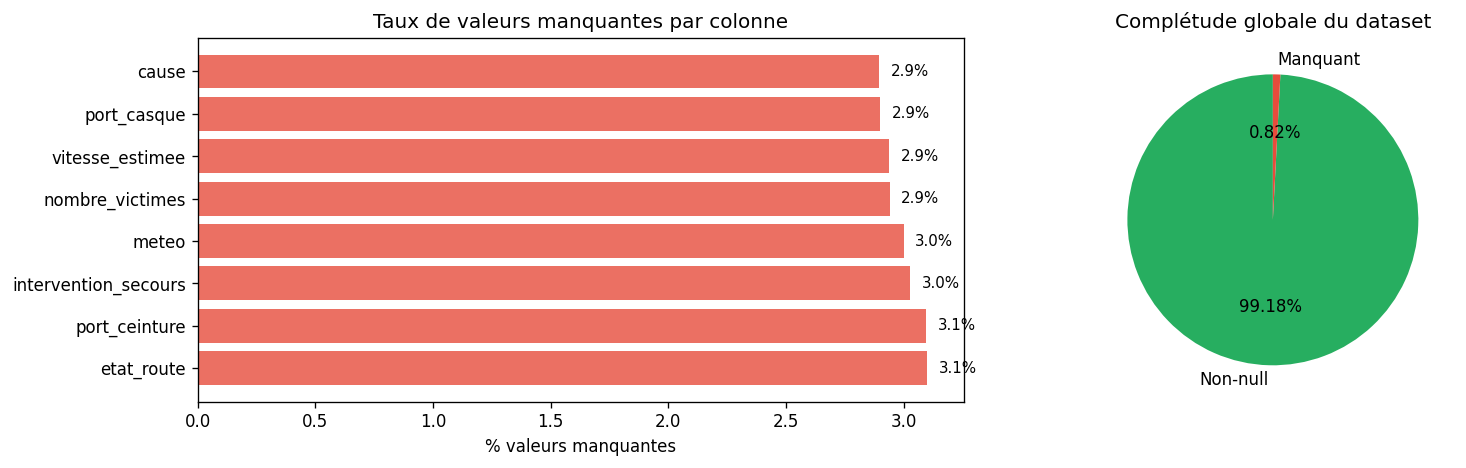

Total valeurs manquantes : 12,067
Taux de complétude global : 99.18%


In [27]:
import missingno as msno

nulls = df.isnull().sum().sort_values(ascending=False)
nulls = nulls[nulls > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Barres des valeurs manquantes
nulls_pct = (nulls / len(df) * 100)
axes[0].barh(nulls.index, nulls_pct, color='#e74c3c', alpha=0.8)
axes[0].set_xlabel('% valeurs manquantes')
axes[0].set_title('Taux de valeurs manquantes par colonne')
for i, (col, pct) in enumerate(nulls_pct.items()):
    axes[0].text(pct + 0.05, i, f'{pct:.1f}%', va='center', fontsize=9)

# Distribution globale
axes[1].pie(
    [df.count().sum(), df.isnull().sum().sum()],
    labels=['Non-null', 'Manquant'],
    colors=['#27ae60', '#e74c3c'],
    autopct='%1.2f%%',
    startangle=90
)
axes[1].set_title('Complétude globale du dataset')

plt.tight_layout()
plt.savefig('../reports/figures/01_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total valeurs manquantes : {df.isnull().sum().sum():,}')
print(f'Taux de complétude global : {(1 - df.isnull().mean().mean())*100:.2f}%')

## 5. Exploration des variables catégorielles

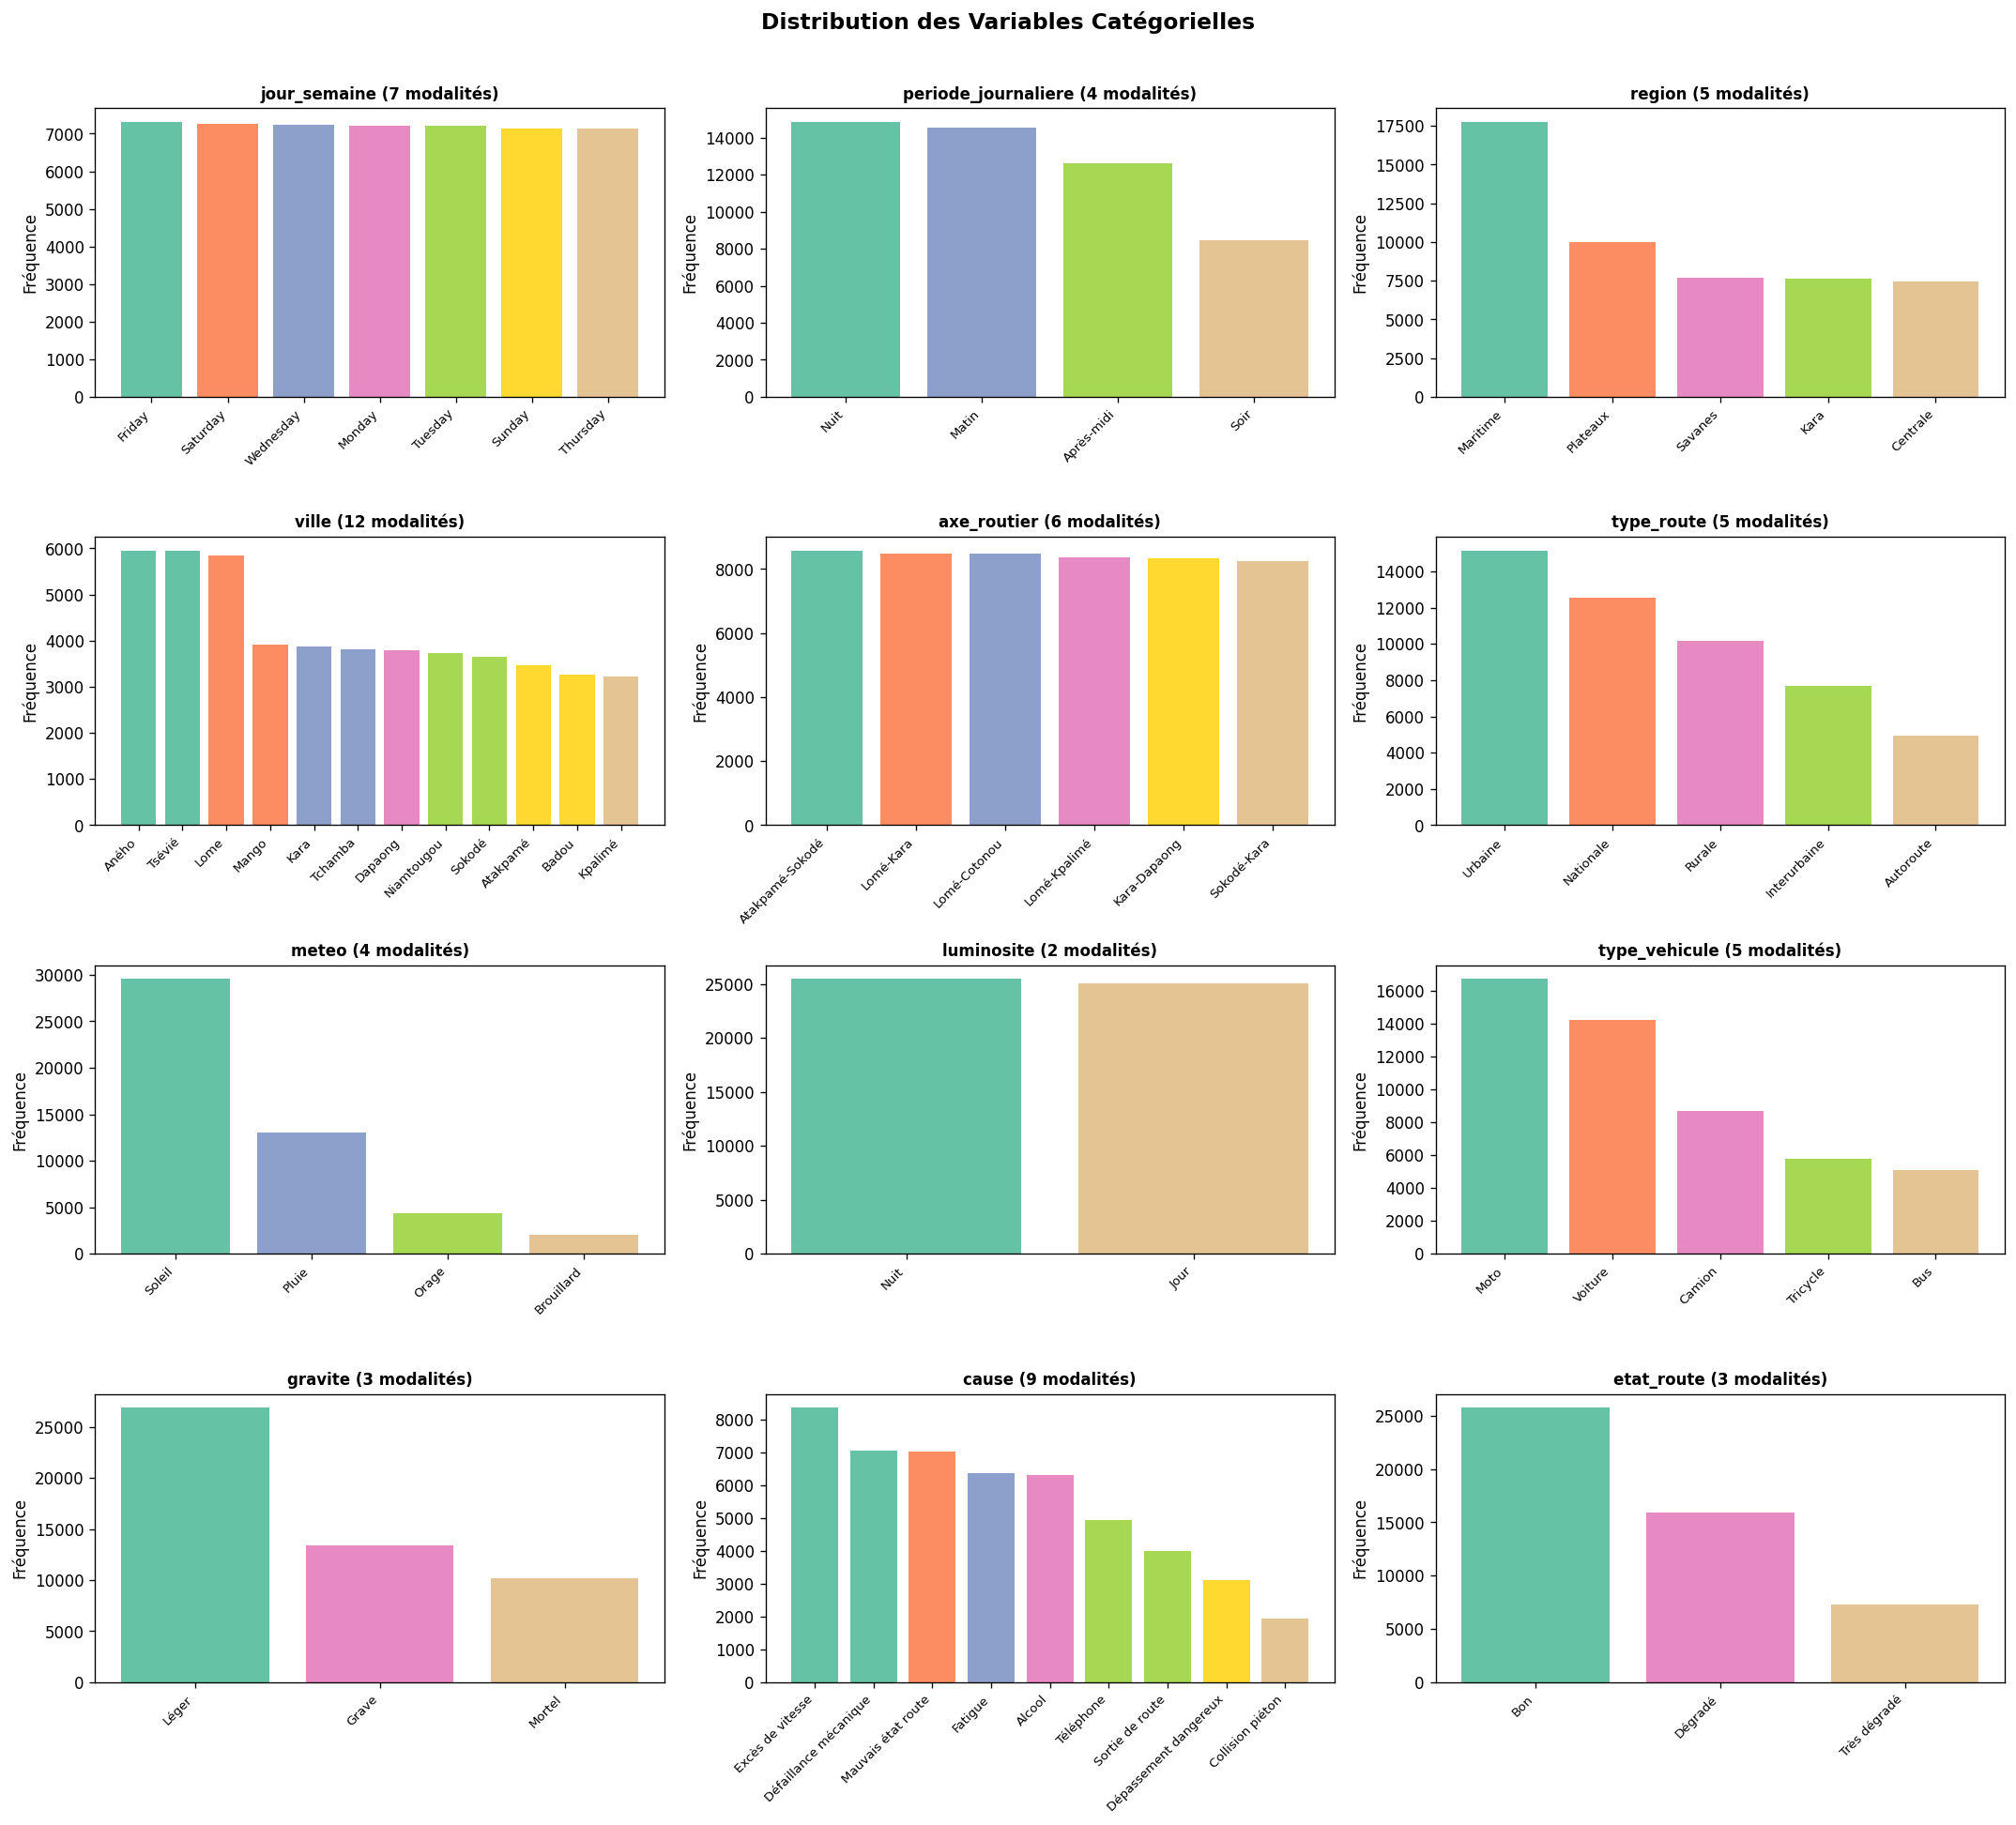

In [28]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols[:12]):
    vc = df[col].value_counts()
    axes[i].bar(range(len(vc)), vc.values, color=plt.cm.Set2(np.linspace(0, 0.8, len(vc))))
    axes[i].set_xticks(range(len(vc)))
    axes[i].set_xticklabels(vc.index, rotation=45, ha='right', fontsize=8)
    axes[i].set_title(f'{col} ({vc.nunique()} modalités)', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Fréquence')

plt.suptitle('Distribution des Variables Catégorielles', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/01_cat_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Exploration des variables numériques

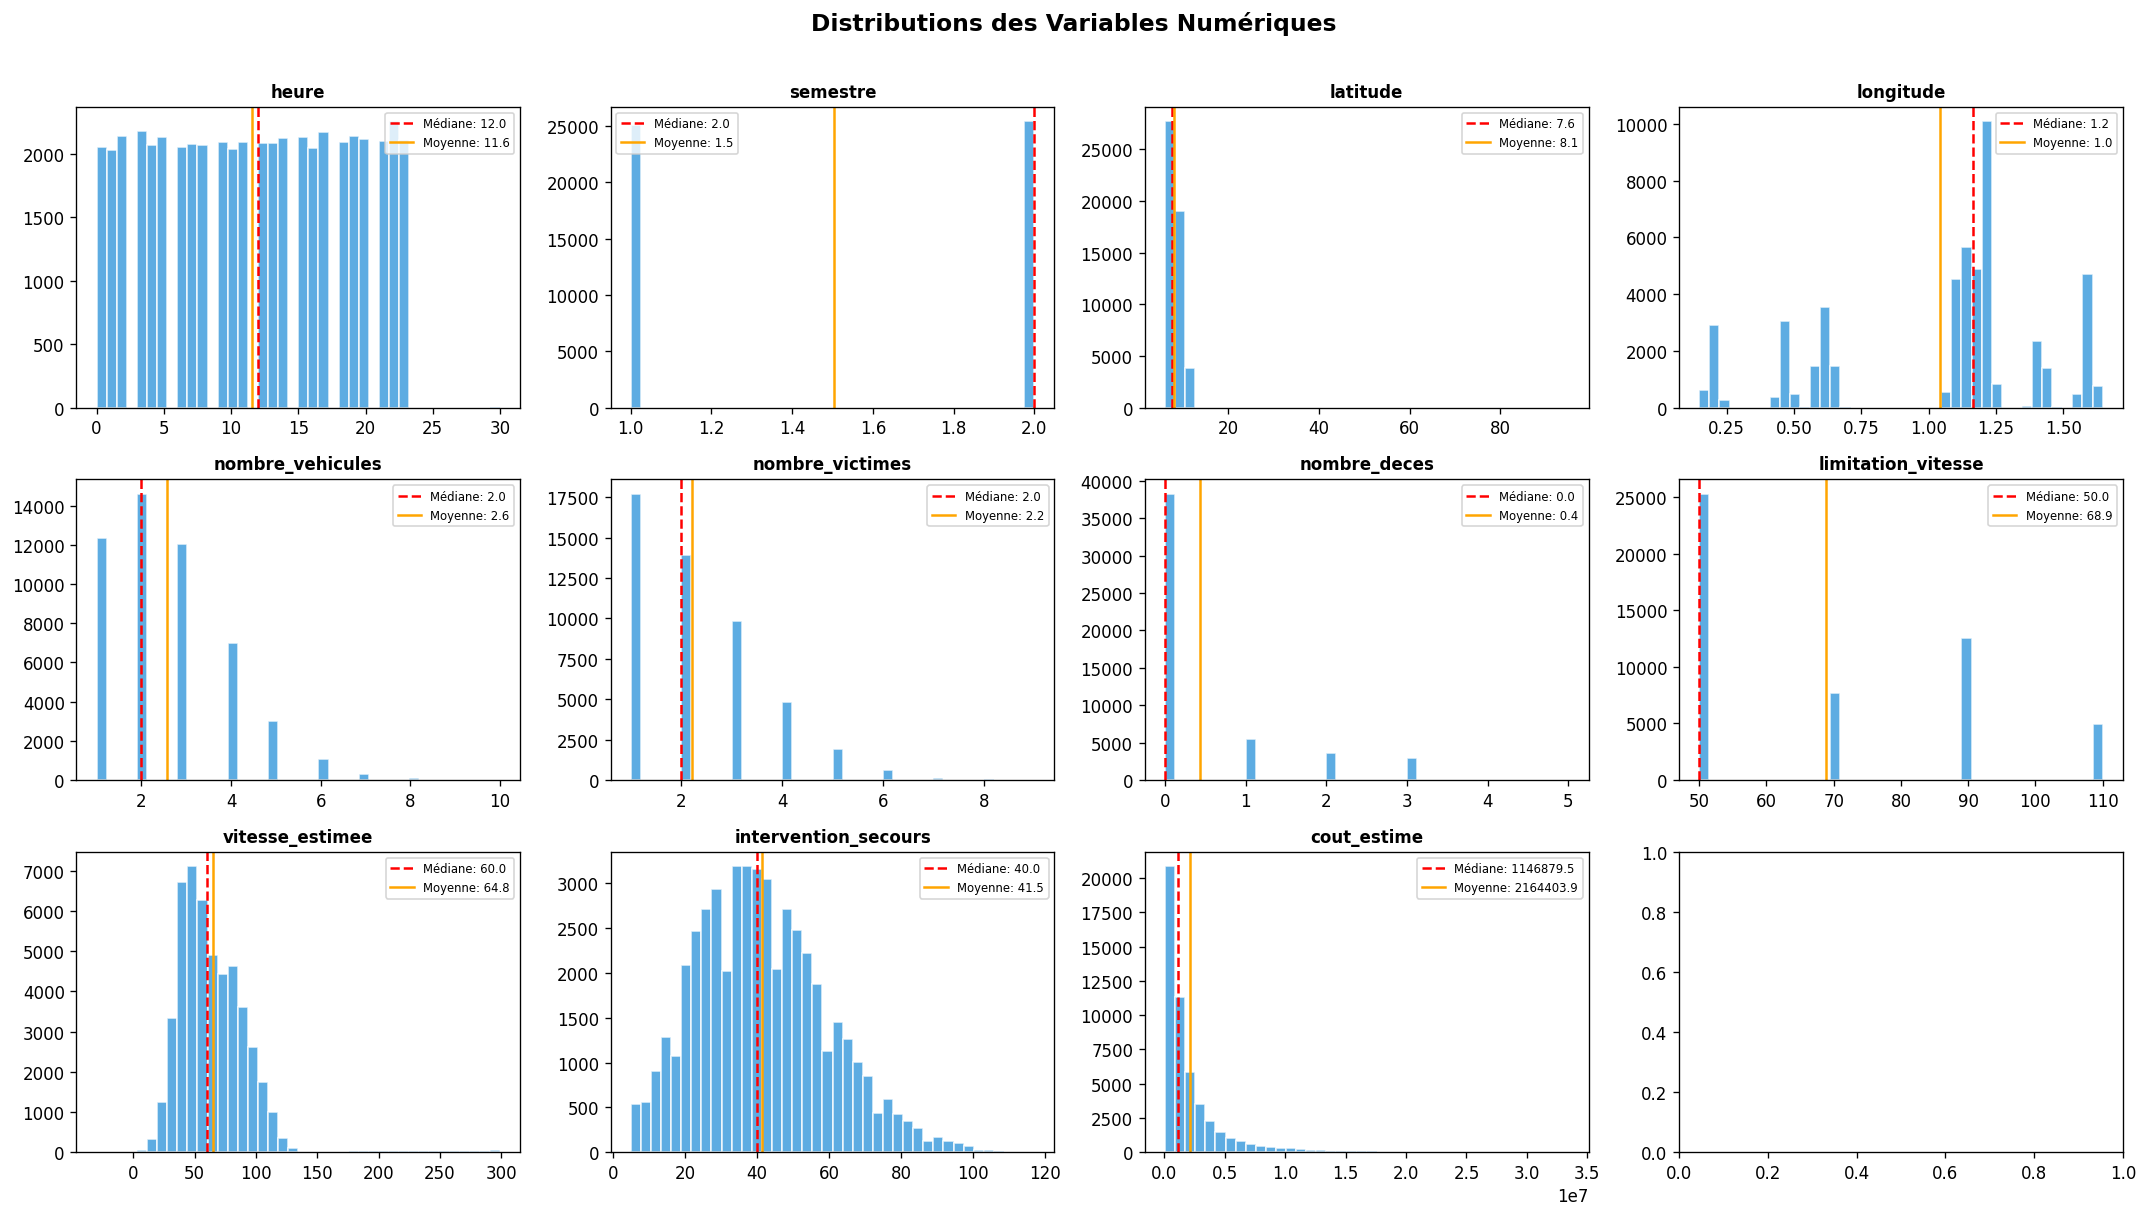

,heure,semestre,latitude,longitude,nombre_vehicules,nombre_victimes,nombre_deces,limitation_vitesse,vitesse_estimee,intervention_secours,cout_estime
count,50500.00,50500.00,50500.00,50500.00,50500.00,49015.00,50500.00,50500.00,49017.00,48972.00,50500.00
mean,11.57,1.50,8.07,1.04,2.58,2.22,0.43,68.89,64.85,41.46,2164403.89
std,6.94,0.50,1.84,0.40,1.35,1.25,0.87,21.36,29.62,18.06,2798703.47
min,0.00,1.00,6.07,0.15,1.00,1.00,0.00,50.00,-30.00,5.00,62689.00
25%,6.00,1.00,6.41,0.63,2.00,1.00,0.00,50.00,45.00,28.00,556205.75
50%,12.00,2.00,7.57,1.16,2.00,2.00,0.00,50.00,60.00,40.00,1146879.50
75%,18.00,2.00,9.56,1.22,3.00,3.00,0.00,90.00,81.00,53.00,2532222.50
max,30.00,2.00,95.00,1.65,10.00,9.00,5.00,110.00,299.00,117.00,33434640.00


In [29]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols_viz = [c for c in num_cols if c not in ['accident_id']]

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols_viz[:12]):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='#3498db', alpha=0.8, edgecolor='white')
    axes[i].axvline(data.median(), color='red', linestyle='--', linewidth=1.5, label=f'Médiane: {data.median():.1f}')
    axes[i].axvline(data.mean(), color='orange', linestyle='-', linewidth=1.5, label=f'Moyenne: {data.mean():.1f}')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=7)

plt.suptitle('Distributions des Variables Numériques', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/01_num_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

df[num_cols_viz].describe().round(2)

## 7. Anomalies détectées — Rapport initial

In [30]:
anomalies = {}

# Heures hors plage 0-23
anomalies['heure_hors_plage'] = ((df['heure'] < 0) | (df['heure'] > 23)).sum()

# Coûts négatifs
anomalies['cout_negatif'] = (df['cout_estime'] < 0).sum()

# Décès > victimes
anomalies['deces_sup_victimes'] = (df['nombre_deces'] > df['nombre_victimes']).sum()

# Vitesses > 200 km/h
anomalies['vitesse_aberrante'] = (df['vitesse_estimee'] > 200).sum()

# Doublons
anomalies['doublons'] = df.duplicated(subset=['accident_id']).sum()

anomaly_df = pd.DataFrame.from_dict(anomalies, orient='index', columns=['Nombre'])
anomaly_df['% du dataset'] = (anomaly_df['Nombre'] / len(df) * 100).round(3)
anomaly_df['Action'] = [
    'Correction par modulo 24',
    'Remplacement par médiane',
    'Suppression de la ligne',
    'Plafonnement à 200 km/h',
    'Déduplication'
]

print('═' * 60)
print('RAPPORT D\'ANOMALIES INITIALES')
print('═' * 60)
print(anomaly_df.to_string())
print('\n→ Ces anomalies seront corrigées dans le notebook 02_data_cleaning.ipynb')

════════════════════════════════════════════════════════════
RAPPORT D'ANOMALIES INITIALES
════════════════════════════════════════════════════════════
                    Nombre  % du dataset                    Action
heure_hors_plage         8          0.02  Correction par modulo 24
cout_negatif             0          0.00  Remplacement par médiane
deces_sup_victimes      10          0.02   Suppression de la ligne
vitesse_aberrante      423          0.84   Plafonnement à 200 km/h
doublons               500          0.99             Déduplication

→ Ces anomalies seront corrigées dans le notebook 02_data_cleaning.ipynb


## 8. Statistiques de la variable cible (gravite)

In [31]:
target_dist = df['gravite'].value_counts()
target_pct  = df['gravite'].value_counts(normalize=True) * 100

target_df = pd.DataFrame({'Nombre': target_dist, 'Pourcentage (%)': target_pct.round(2)})
print('Distribution de la variable cible (gravite) :')
print(target_df)

# Calcul du déséquilibre
majority_pct = target_pct.max()
minority_pct = target_pct.min()
print(f'\nRatio déséquilibre : {majority_pct/minority_pct:.1f}:1')
print('→ Imbalanced dataset : utiliser class_weight="balanced" ou SMOTE')

Distribution de la variable cible (gravite) :
         Nombre  Pourcentage (%)
gravite                         
Léger     26881            53.23
Grave     13410            26.55
Mortel    10209            20.22

Ratio déséquilibre : 2.6:1
→ Imbalanced dataset : utiliser class_weight="balanced" ou SMOTE


In [32]:
# Sauvegarde du rapport
report = {
    'shape': df.shape,
    'periode': f"{df['date_accident'].min().date()} → {df['date_accident'].max().date()}",
    'nb_colonnes': df.shape[1],
    'nb_lignes': df.shape[0],
    'completude_pct': round((1 - df.isnull().mean().mean()) * 100, 2),
    'nb_anomalies': sum(anomalies.values()),
    'target_distribution': target_df.to_dict()
}

import json
with open('../reports/tables/01_collection_report.json', 'w', encoding='utf-8') as f:
    json.dump(report, f, ensure_ascii=False, indent=2, default=str)

print('✓ Rapport sauvegardé dans reports/tables/01_collection_report.json')
print('\n→ Prochaine étape : notebook 02_data_cleaning.ipynb')

✓ Rapport sauvegardé dans reports/tables/01_collection_report.json

→ Prochaine étape : notebook 02_data_cleaning.ipynb
